# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [1]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json

from langchain_core.messages import HumanMessage

from network_manager_agent import (
    LLMConfig,
    build_agent,
    create_llm,
)
from network_manager_agent.data import DataManager

## Load and Pre-compute Data: Filter & Aggregate (done by DataManager)

In [2]:
county_specialty_thresholds = {
    "mi": {
        "wayne": {"general practice": 10.0, "cardiology": 15.0},
        "washtenaw": {"general practice": 10.0, "cardiology": 15.0},
    }
}

dm = DataManager(county_specialty_thresholds=county_specialty_thresholds)
candidates = dm.get_candidates_df()
members = dm.get_members_df()

print(f"Loaded {len(candidates)} candidates, {len(members)} members")

Loaded 85615 candidates, 12051 members


## Create LLM

In [3]:
llm_config = LLMConfig(base_url="http://localhost:8080/v1")
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")

In [4]:
content = response.content.strip()
print(f"LLM response: {content}")

LLM response: Hey! 👋 Yep, I'm up and running smoothly. Thanks for checking in! What can I help you with today? 😊


In [5]:
reasoning = response.additional_kwargs.get("reasoning_content", "No reasoning provided")
print(f"LLM reasoning: {reasoning}")

LLM reasoning: Here's a thinking process:

1.  **Analyze User Input:**
   - **Input:** "Hey there! Just making sure you're up and running!"
   - **Intent:** Casual greeting/check-in to verify system status
   - **Tone:** Friendly, informal
   - **Expected Response:** Acknowledge the greeting, confirm operational status, match the friendly tone, and invite further interaction

2.  **Identify Key Requirements:**
   - Confirm I'm operational
   - Keep it warm and conversational
   - Offer assistance
   - Keep it concise

3.  **Draft Response (Mental):**
   Hey! 👋 Yep, I'm up and running smoothly. Thanks for checking in! What can I help you with today?

4.  **Refine Response (Self-Correction/Verification):**
   - Matches tone? Yes, friendly and casual
   - Confirms status? Yes
   - Invites next step? Yes
   - Concise? Yes
   - No overpromising or unnecessary details? Yes

   All good. Ready to output.✅



## Build Agent

In [6]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = str(Path.cwd().parent / "checkpoints.sqlite")
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = build_agent(llm, checkpointer=checkpointer)
print("Agent built successfully!")


Agent built successfully!


## Visualize Graph

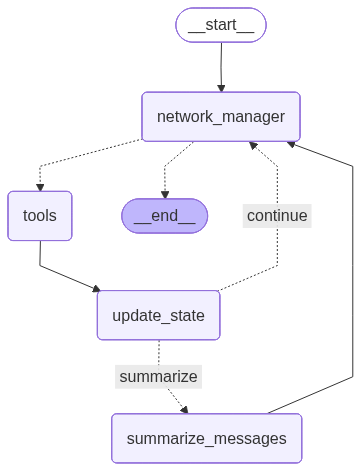

In [7]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Run the Agent

In [8]:
from network_manager_agent.ui import run_agent


def run_agent_demo(agent, inputs: dict, config: dict):
    """Wrapper for run_agent that matches the notebook's naming convention."""
    run_agent(agent, inputs, config)


In [9]:
# Create a thread
config = {"configurable": {"thread_id": "test_notebook2"}}


In [10]:
# Specify an input
messages = [HumanMessage(content='''
Find 5 large health systems (show in the entities column) that have high geographic proximity to our members. 
Then calculate the actual coverage they would provide to the network.
Then create a balanced score between that and effectivenes. Rank them and present back to me in table format.
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "sandbox_cache": {},
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL: run_code ---
    # First, let's understand the data and compute entity-level statistics
    # Calculate member centroid for each county to assess proximity
    
    # Get member locations by county
    member_centroids = members_df.groupby(['state', 'county']).agg(
        member_lat=('lat', 'mean'),
        member_lon=('lon', 'mean'),
        member_count=('id', 'count')
    ).reset_index()
    
    print("Member distribution by county:")
    print(member_centroids)
    
    # Get entity-level statistics from candidates
    entity_stats = candidates_df.groupby('entity').agg(
        provider_count=('id', 'count'),
        avg_effectiveness=('effectiveness', 'mean'),
        avg_efficiency=('efficiency', 'mean'),
        avg_lat=('lat', 'mean'),
        avg_lon=('lon', 'mean'),
        specialties=('specialty', lambda x: list(x.unique()))
    ).reset_index()
    
    print("\nTop 20 entities by provider cou

In [13]:
# Specify an input
messages = [HumanMessage(content='''
Follow up here
''')]

inputs = {
    "messages": messages
}

# run_agent_demo(agent, inputs, config)


In [14]:
# Specify an input
messages = [HumanMessage(content='''
Follow up here
''')]

inputs = {
    "messages": messages
}

# run_agent_demo(agent, inputs, config)

## Inspect Agent State

In [15]:
# Show the last human message from the conversation
state = agent.get_state(config)
messages = state.values.get("messages", [])
last_human = [m for m in reversed(messages) if m.type == 'human']
print("Last human message:")
print(last_human[0].content if last_human else "(none)")


Last human message:
(none)


In [16]:
print("Summary:")
print(state.values.get("summary", "(empty)"))

print()

print("Schema profile:")
schema = state.values.get("schema_profile", "")
print(f"  {len(schema)} chars" if schema else "  (empty)")


Summary:
Objective: Find 5 large health systems (show in the entities column) that have high geographic proximity to our members. 
Then calculate the actual coverage they would provide to the network.
Then create a balanced score between that and effectivenes. Rank them and present back to me in table format.

Progress: Loaded and processed the CANDIDATES dataset (85,615 rows, 21 columns) and MEMBERS dataset (12,051 rows, 11 columns). Verified member distribution across target counties (Wayne: 10,257; Washtenaw: 1,794). Identified exactly 8,609 unique health system entities from the candidate pool. Ranked all entities by total provider count and compiled the top 30 systems to prepare for subsequent metric aggregation.

Key Findings: Members are concentrated in target counties: Wayne (10,257) and Washtenaw (1,794), totaling 12,051 members. Top health systems by provider count: MyMichigan Health: 8,684 providers; Corewell Health: 8,506 providers; Henry Ford Health: 5,135 providers; Trini

In [17]:
import pandas as pd
print("Current network (list of entity IDs):")
network = agent.get_state(config).values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty - no entities added yet)")


Current network (list of entity IDs):
  (empty - no entities added yet)


## Try a More Complex Prompt

In [18]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
Complex prompt here
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
}

# run_agent_demo(agent, inputs, config)


In [19]:
# # Check final state
# state = agent.get_state(config)
# print("Summary:")
# print(state.values.get("summary", "(empty)"))

# print("\nNetwork (entity IDs):")
# network = state.values.get("network", [])
# if network:
#     for i, entity_id in enumerate(network, 1):
#         print(f"  {i}. {entity_id}")
# else:
#     print("  (empty)")
